In [2]:
#pip install pandas numpy matplotlib seaborn soundfile

In [3]:
import pandas as pd
import numpy as np
import soundfile as sf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

To study our dataset we’ve performed an exploratory data analysis on it. We looked at distributions, outliers, and other statistics present in our data. 
This analysis was done after our initial preprocessing and segmentation. This means that the segments are 3 seconds long and that there are no augmented data present yet. This analysis focused on getting the initial information about the dataset as well as seeing the difference between normalized data and raw data.


We used python and it’s libraries such as pandas, numpy, soundfile, matplotlib and seaborn.

paths to the data:

In [4]:

raw_dir = Path("raw_data")
norm_dir = Path("norm_data")


extracting the features (metadata) from the filename of the segments:

In [5]:
filename_pattern = re.compile(r"(class[01])_([a-zA-Z0-9]+)_(\d+)_(\d+)\.wav$")

# here filepath is the path to a specific .wav segment. the function extracts metadata from one segment
def extract_metadata(filepath: Path):
    match = filename_pattern.match(filepath.name)
    if match:
        class_number, speaker, recording_id, segment_id = match.groups()
        data,sample_rate=sf.read(filepath)

        if sample_rate is None or sample_rate<=0:
            print("skipped: ",str(filepath.name)," (invalid sample rate)")  
            return
        if data is None or len(data)==0:
            print("skipped: ",str(filepath.name)," (invalid audio, empty audio)")  
            return
        if data.ndim==2:
            data = data.mean(axis=1) # all data is mono 

        mean_amp = float(np.mean(np.abs(data)))
        std_amp = float(np.std(data)) # standard deviation of ampitude
        max_amp = float(np.max(np.abs(data)))
        duration = float(len(data)/sample_rate)


        return{
            "dataset_type": filepath.parts[-5], # norm or raw
            "dataset_split": filepath.parts[-4], # validation or train or test
            "class_number": int(class_number[-1]),
            "class_name":class_number,
            "speaker": speaker,
            "recording_id": int(recording_id),
            "segment_id": int(segment_id),
            "path": str(filepath),
            "duration": duration,
            "mean_amp": mean_amp, # mean absolute ampitude
            "std_amp": std_amp,
            "max_amp": max_amp,
            "sample_rate": sample_rate

        }

    else:
        print("skipped: ",str(filepath.name)," (invalid filename format)")    

    


collecting all data set segments in one data frame:

In [6]:
def collect_dataset(base_path:Path):
    rows=[]
    for file in base_path.rglob("*.wav"):
        metadata = extract_metadata(file)
        if metadata:
            rows.append(metadata)
    return pd.DataFrame(rows)

In [7]:
df_raw = collect_dataset(raw_dir)
df_norm= collect_dataset(norm_dir)

skipped:  class1_swift_1_000(1).wav  (invalid filename format)
skipped:  class1_swift_1_001(1).wav  (invalid filename format)
skipped:  class1_swift_1_002(1).wav  (invalid filename format)
skipped:  class1_swift_1_003(1).wav  (invalid filename format)
skipped:  class1_swift_1_004(1).wav  (invalid filename format)
skipped:  class1_swift_1_005(1).wav  (invalid filename format)
skipped:  class1_swift_1_006(1).wav  (invalid filename format)
skipped:  class1_swift_1_007(1).wav  (invalid filename format)
skipped:  class1_swift_1_008(1).wav  (invalid filename format)
skipped:  class1_swift_1_009(1).wav  (invalid filename format)
skipped:  class1_trisha_1_026(1).wav  (invalid filename format)
skipped:  class1_trisha_1_030(1).wav  (invalid filename format)
skipped:  class1_trisha_1_031(1).wav  (invalid filename format)
skipped:  class1_trisha_1_032(1).wav  (invalid filename format)
skipped:  class0_blanchett_3_151(1).wav  (invalid filename format)
skipped:  class0_blanchett_3_152(1).wav  (inval

In [8]:
print("raw: ",df_raw.shape)
print("raw: ",df_norm.shape)

df_raw.head()

raw:  (5043, 13)
raw:  (5043, 13)


,dataset_type,dataset_split,class_number,class_name,speaker,recording_id,segment_id,path,duration,mean_amp,std_amp,max_amp,sample_rate
0,raw_data,test_data,0,class0,attenborough,1,0,raw_data\test_data\class_0\attenborough_1\clas...,3.0,0.032750,0.054790,0.514893,16000
1,raw_data,test_data,0,class0,attenborough,1,1,raw_data\test_data\class_0\attenborough_1\clas...,3.0,0.047592,0.075833,0.536133,16000
2,raw_data,test_data,0,class0,attenborough,1,2,raw_data\test_data\class_0\attenborough_1\clas...,3.0,0.052007,0.084116,0.591339,16000
3,raw_data,test_data,0,class0,attenborough,1,3,raw_data\test_data\class_0\attenborough_1\clas...,3.0,0.056262,0.086956,0.897003,16000
4,raw_data,test_data,0,class0,attenborough,1,4,raw_data\test_data\class_0\attenborough_1\clas...,3.0,0.055939,0.087287,0.491577,16000


After loading the whole database we firstly looked at the shape of the dataset. The shape of both raw and normalized data was (5043,13). This meant that there were in total 5043 3-second segments. For each of them we had 13 attributes that were useful for the analysis. Those were the following: dataset_type, dataset_split, class_number, class_name, speaker, recording_id, segment_id, path, duration, mean_amp, std_amp, max_amp, sample_rate.


Next we looked at some comparisons between classes in the raw dataset. We can only analyze the raw data set in this subsection, because we know that the data split between classes is exactly the same for normalized data, only the data itself is different.


number of recordings per class

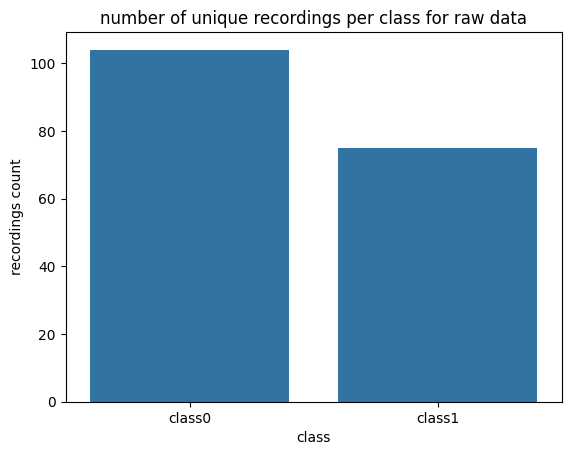

In [9]:
unique_recordings = (
    df_raw.groupby(["class_name","speaker"])["recording_id"]
        .nunique()
        .groupby("class_name")
        .sum()
        .reset_index(name="num_recordings")
)

sns.barplot(data=unique_recordings,x="class_name",y="num_recordings")
plt.title("number of unique recordings per class for raw data")
plt.ylabel("recordings count")
plt.xlabel("class")
plt.show()


This plot shows the difference between the number of unique recordings per class for raw data. Class 0 contains slightly more samples than Class 1. This indicates a moderate class imbalance, with Class 0 being more frequent. However it is still important to note it, as this imbalance may influence the training of the model and we still need to consider it when analyzing the results of our model.


number of speakers

  class_name  speaker_count
0     class0             21
1     class1              5


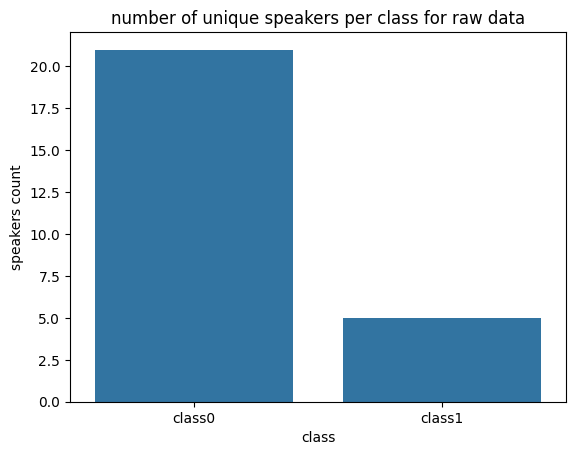

In [10]:
speaker_count = (
    df_raw.groupby(["class_name"])["speaker"].nunique().reset_index(name="speaker_count")
)
print(speaker_count)

sns.barplot(data=speaker_count,x="class_name",y="speaker_count")
plt.title("number of unique speakers per class for raw data") #this also counts the random speakers as one
plt.ylabel("speakers count")
plt.xlabel("class")
plt.show()

This plot displays the number of unique speakers in each class for raw data. Class 0 contains recordings from 21 different speakers, while Class 1 includes only 5 speakers. This matches our choices when collecting the data, where we particularly wanted this imbalance to occur as to make the Class 0 represent a wide variety of the population, whereas the Class 1 is only few specific people. 
Initially this might seem like this plot shows a strong imbalance in speaker representation between two classes, and that such imbalance could affect the model’s ability to generalize well, however it’s important to understand that we do not want to generalize that much, since Class 1 is the validated class, that consists of only specific people that can have access to some secured assets. Instead of generalization, we want our model to learn and recognize the speakers from Class 1, while treating all other voices as Class 0. 


avg number of recordings per speaker for each class

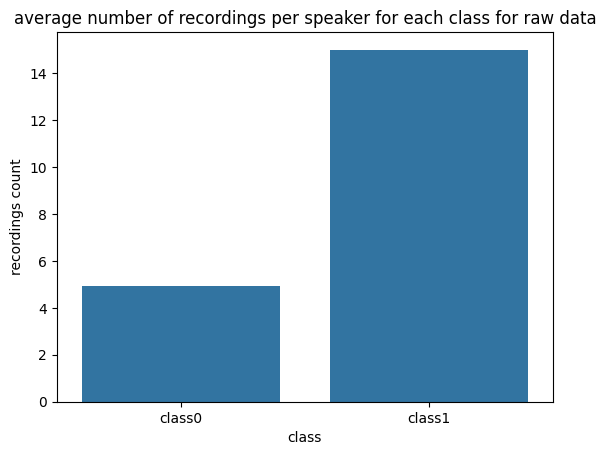

In [11]:
recordings_per_speaker =(
    df_raw.groupby(["class_name","speaker"])["recording_id"]
        .nunique()
        .groupby("class_name")
        .mean()
        .reset_index(name="mean_rec_per_speaker")
)


sns.barplot(data=recordings_per_speaker,x="class_name",y="mean_rec_per_speaker")
plt.title("average number of recordings per speaker for each class for raw data") #this also counts the random speakers as one
plt.ylabel("recordings count")
plt.xlabel("class")
plt.show()




This plot shows the average number of recordings per speaker in each class. It’s important to note here that all recordings are relatively of the same length (around 60-90 seconds). In Class 0, there are many different speakers, but each speaker has relatively few recordings, around 5. This provides speaker diversity without making the dataset heavily imbalanced between the two classes. In Class 1 that contains fewer speakers, each speaker has a larger number of recordings. This ensures that the model receives enough data to accurately learn and recognize the authorized voices belonging to the validated class.


this shows that class 0 has many speakers but there is less recordings for them to have diversity without making the imbalance between class0/1 too large

where as in the class1 we have less speakers butmore recordings to ensure the model can recognize these voices more

duration:

In [12]:
df_raw.groupby("class_name")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
class0,2626.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0
class1,2417.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0


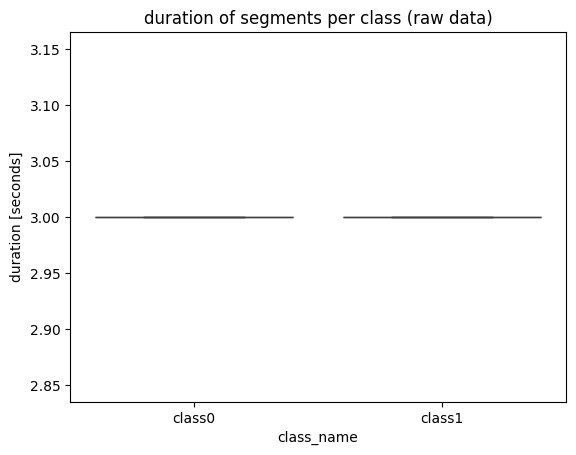

In [13]:
sns.boxplot(data=df_raw, x="class_name", y="duration")
plt.title("duration of segments per class (raw data)")
plt.ylabel("duration [seconds]")
plt.show()

This plot comparing the duration of segments per class proves that the preprocessing and segmentation was done correctly, and that every segment, later on a spectrogram, is of the same unified length, equal to 3 seconds.


we see that the segments are all of the same duration and are consistent

comparing ampitude statistics with raw and normalized data:

In [14]:
df_raw.groupby("class_name")[["mean_amp","std_amp","max_amp"]].describe().round(4)

mean_amp                                                          \
              count    mean     std     min     25%     50%     75%     max   
class_name                                                                    
class0       2626.0  0.0510  0.0324  0.0028  0.0274  0.0467  0.0640  0.2612   
class1       2417.0  0.0546  0.0292  0.0058  0.0289  0.0536  0.0736  0.1831   

           std_amp          ...                 max_amp                  \
             count    mean  ...     75%     max   count    mean     std   
class_name                  ...                                           
class0      2626.0  0.0772  ...  0.0956  0.3621  2626.0  0.5092  0.2496   
class1      2417.0  0.0820  ...  0.1089  0.2479  2417.0  0.5271  0.2266   

                                                 
               min     25%     50%     75%  max  
class_name                                       
class0      0.0305  0.3122  0.5021  0.6835  1.0  
class1      0.0627  0.3492  0.5371  0.6769  1.0  

[2 rows x 24 columns]

In [15]:
df_norm.groupby("class_name")[["mean_amp","std_amp","max_amp"]].describe().round(4)

mean_amp                                                          \
              count    mean     std     min     25%     50%     75%     max   
class_name                                                                    
class0       2626.0  0.0998  0.0299  0.0281  0.0781  0.0969  0.1175  0.2772   
class1       2417.0  0.1034  0.0331  0.0258  0.0796  0.0979  0.1225  0.2907   

           std_amp          ...                 max_amp                      \
             count    mean  ...     75%     max   count mean  std  min  25%   
class_name                  ...                                               
class0      2626.0  0.1508  ...  0.1742  0.3526  2626.0  1.0  0.0  1.0  1.0   
class1      2417.0  0.1549  ...  0.1796  0.3606  2417.0  1.0  0.0  1.0  1.0   

                           
            50%  75%  max  
class_name                 
class0      1.0  1.0  1.0  
class1      1.0  1.0  1.0  

[2 rows x 24 columns]

the normalization increased the average ampitude of the segments, the difference between classes also is small in terms of ampitude, and the normalization made the max ampitude of segments peak at the same value 1.0

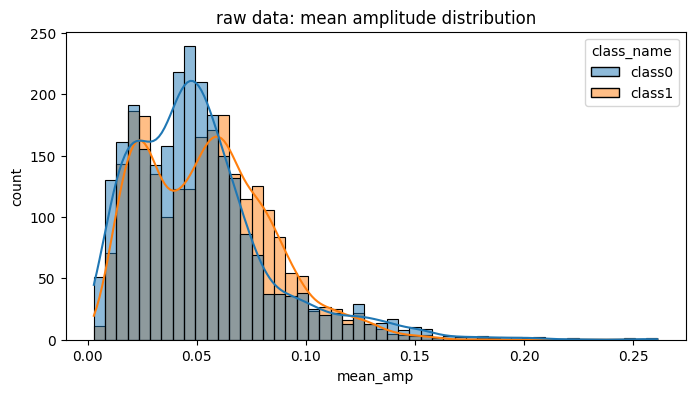

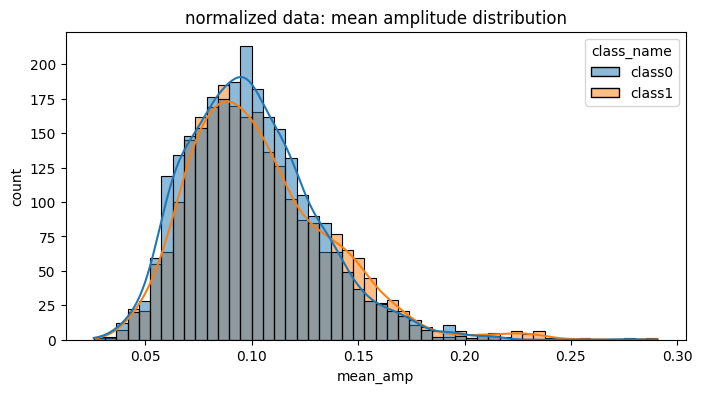

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(df_raw, x="mean_amp", hue="class_name", bins=50, kde=True)
plt.title("raw data: mean amplitude distribution")
plt.xlabel("mean_amp")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_norm, x="mean_amp", hue="class_name", bins=50, kde=True)
plt.title("normalized data: mean amplitude distribution")
plt.xlabel("mean_amp")
plt.ylabel("count")
plt.show()

These histograms show the mean amplitude distribution for normalized and raw datasets. In the raw data, both classes follow a similar right-skewed distribution, with a long tail toward higher amplitudes. This explains the presence of several outliers later on shown in the boxplots, which correspond to speech segments that are naturally louder than most others rather than to corrupted data.
After normalization, the distributions of both classes become more aligned and centered, which reduces variability caused by recording volume differences. This helps the model focus on user specific features rather than differences in loudness of the recording.


this also shows why there are so many outliers, since the long right talk extends towards 0.25 it corresponds to the outliers showed later in the boxplots, these are normal segments that are just louder than most others

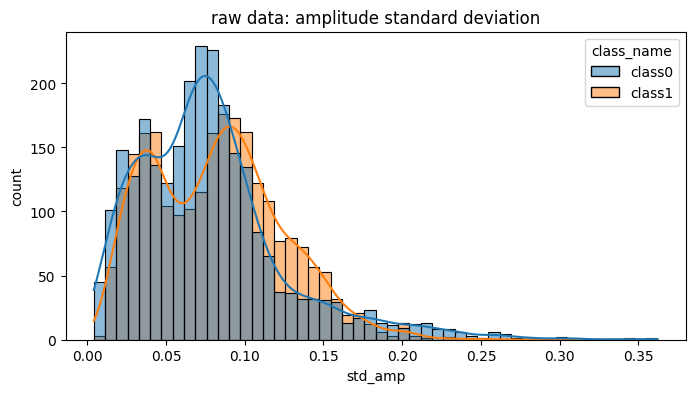

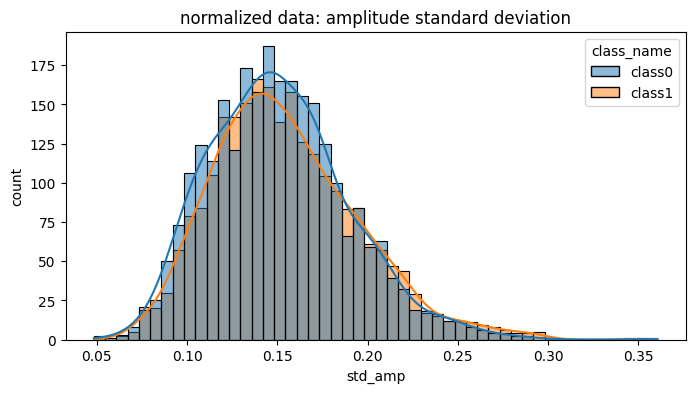

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(df_raw, x="std_amp", hue="class_name", bins=50, kde=True)
plt.title("raw data: amplitude standard deviation")
plt.xlabel("std_amp")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_norm, x="std_amp", hue="class_name", bins=50, kde=True)
plt.title("normalized data: amplitude standard deviation")
plt.xlabel("std_amp")
plt.ylabel("count")
plt.show()

These histograms show the distribution of the amplitude standard deviation for classes before and after normalization. 
In the raw data, both classes present a right-skewed distribution with a long tail toward higher values, indicating the presence of segments with higher signal variability. The distributions of the two classes are similar, with no clear separation based on this feature alone.
After normalization, the distributions become more centered and closely aligned between the two classes. This reduces differences caused by recording conditions and overall loudness, again helping the model focus on speaker-related characteristics rather than amplitude variability.


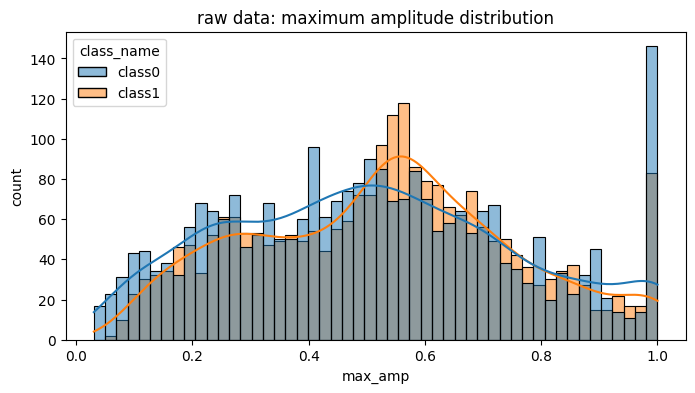

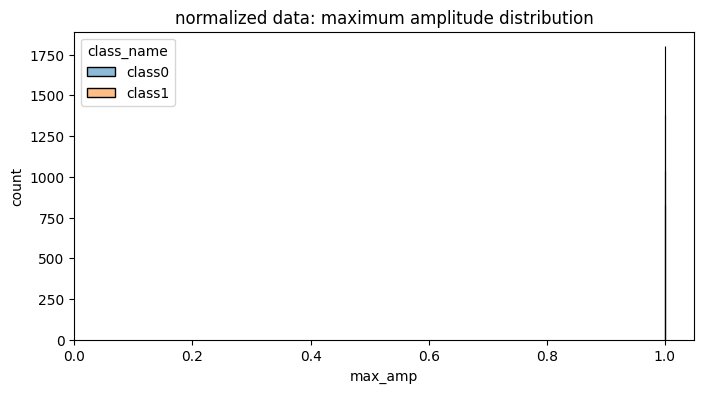

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(df_raw, x="max_amp", hue="class_name", bins=50, kde=True)
plt.title("raw data: maximum amplitude distribution")
plt.xlabel("max_amp")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_norm, x="max_amp", hue="class_name", bins=50, kde=False)
plt.title("normalized data: maximum amplitude distribution")
plt.xlabel("max_amp")
plt.xlim(0.0, 1.05) 
plt.ylabel("count")
plt.show()

These histograms show the maximum amplitude distribution for both raw and normalized data. 
In the raw data, the distributions are spread across a wide range of values and show noticeable variability, with some recordings reaching the maximum possible amplitude. The two classes follow similar patterns, but differences in recording volume may introduce unwanted bias.
As we can see after normalization, all segments reach a maximum amplitude at the constant 1.0. This successfully gets rid of any bias and differences in loudness between recordings and classes. 


the normalization fixed any bias for any of the class regarding ampitude

mean ampitude per speaker in the normalized data:

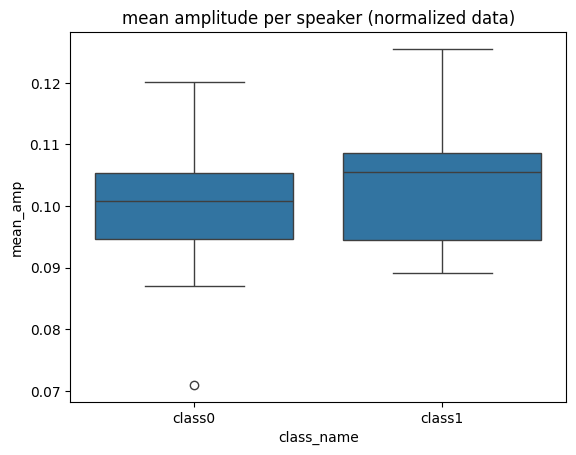

In [19]:
speaker_stats = (
    df_norm.groupby(["class_name", "speaker"])[["mean_amp", "std_amp"]]
        .mean()
        .reset_index()
)

sns.boxplot(data=speaker_stats, x="class_name", y="mean_amp")
plt.title("mean amplitude per speaker (normalized data)")
plt.show()

This boxplot shows the distribution of the mean amplitude per speaker after normalization in both classes. The median and spread are very similar for both classes, indicating that loudness levels are consistent across speakers regardless of class. 
This confirms that normalization successfully scaled all recordings to a comparable amplitude range. 
We can observe one outlier in Class 0, which represents one quieter speaker however this should not significantly affect the model. 


the loudness is relatively the same for all apeakers across both classes, normalization scaled every speaker rougly to the same ampitude range, there is one outlier in class0

mean of standard deviation of the ampitude per speaker in normalized data

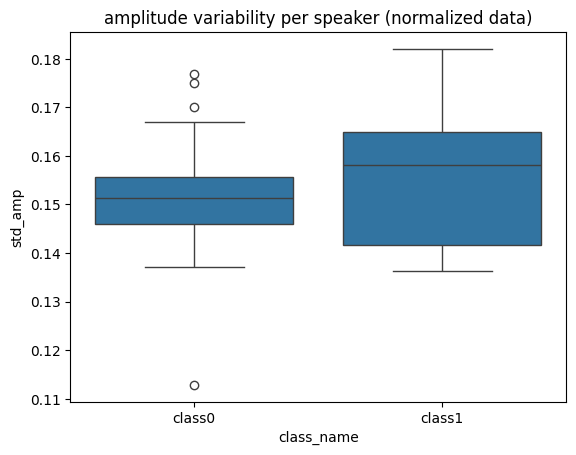

In [20]:

speaker_std_stats=(
    df_norm.groupby(["class_name", "speaker"])[["std_amp"]]
        .mean()
        .reset_index()
)

sns.boxplot(data=speaker_std_stats, x="class_name", y="std_amp")
plt.title("amplitude variability per speaker (normalized data)")
plt.xlabel("class_name")
plt.ylabel("std_amp")
plt.show()

This boxplot shows the distribution of amplitude variability per speaker after normalization. Both classes are centered around similar values which indicates comparable overall variability. 
Class 1 shows a slightly wider spread, which suggests that recordings from authorized speakers are more dynamic on average.
Class 0 exhibits more consistent variability across speakers, with only a few outliers showing higher or lower variation.


both classes are centered around 0.15 so they have similar variablity, class 1 speakers includes more dynamic recordings where the average ampitude standard deviation is bigger accross recordings, 

class 0 is relatively consistent with few speakers having more variability than others

outliers:

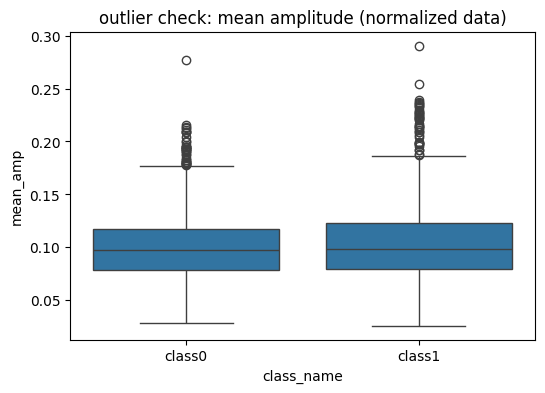

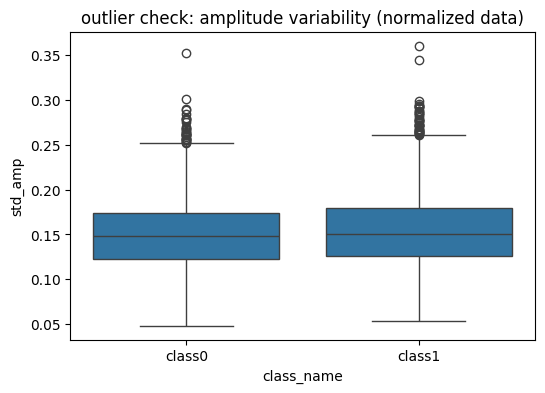

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_norm, x="class_name", y="mean_amp", showfliers=True)
plt.title("outlier check: mean amplitude (normalized data)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df_norm, x="class_name", y="std_amp", showfliers=True)
plt.title("outlier check: amplitude variability (normalized data)")
plt.show()

The boxplots show the presence of outliers in both the mean amplitude and amplitude variability after normalization. This behaviour was already predicted when we observed the distribution on the histograms. These outliers correspond to naturally louder speech segments and recordings with higher variability, rather than to noise or corrupted data. 
Since the distributions and the number of outliers are similar for both classes, no class-specific bias for this needs to be considered. Therefore we kept  the outliers in the dataset, as they represent realistic variations in speech and could help improve the model’s robustness.


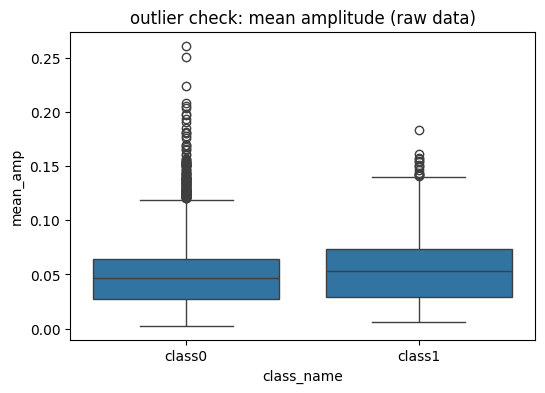

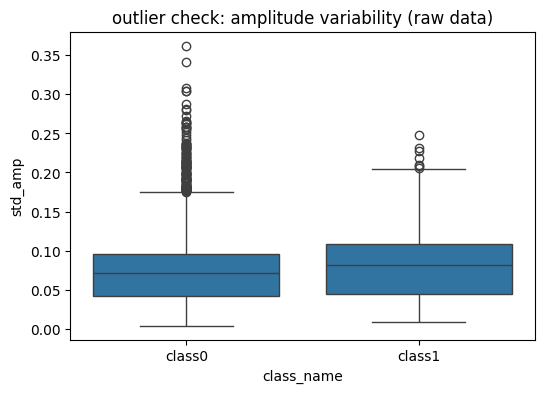

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_raw, x="class_name", y="mean_amp", showfliers=True)
plt.title("outlier check: mean amplitude (raw data)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df_raw, x="class_name", y="std_amp", showfliers=True)
plt.title("outlier check: amplitude variability (raw data)")
plt.show()


This boxplot shows the presence of many high value outliers in both mean amplitude and variability for raw recordings. However, like in the normalized data, these outliers are consistent with the previously observed distributions and mainly correspond to louder or more dynamic speech segments rather than to recording errors.


the outliers fit with the previous graphs showing the distributions of standard deviation or mean in ampitudes, we can say that the distribution is right-skewed

segment count per recording:

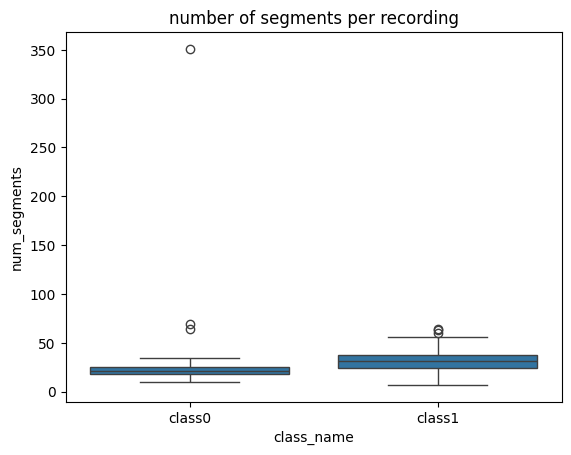

In [23]:
segments_per_recording = (
    df_raw.groupby(["class_name", "speaker", "recording_id"])["segment_id"]
    .nunique()
    .reset_index(name="num_segments")
)

sns.boxplot(data=segments_per_recording, x="class_name", y="num_segments")
plt.title("number of segments per recording")
plt.show()

This boxplot shows the distribution of the number of segments extracted from each recording for both classes. Most recordings in both classes contain a similar number of segments, indicating that the recordings were mostly of uniform length, which helps with consistency. Thanks to this, every recording can be equally represented in the database, which allows it to uniformly represent a speaker's voice in different environments. 
The large outliers in Class 0 correspond to the random speakers which were recorded in only 3 recordings with longer length. 
Overall, the data is distributed fairly uniformly between recordings, and no strong class imbalance is introduced by the segmentation procedure.


the big outliers are recordings of "random" people that had less recordings but they were longer,

but we can say that the data is split uniformly between recordings

sample rate:

In [24]:
print(df_raw["sample_rate"].value_counts())

sample_rate
16000    5043
Name: count, dtype: int64


Another quick sanity check confirms that all segments have the same sample rate equal to 16000.

all recordings have the same rate 

# Conclusion:

The exploratory analysis showed that the dataset is generally well balanced and suitable for training a speaker recognition model. 
